# Thống kê số lượng nhãn chính (L1)

Notebook này đọc dữ liệu từ `raw_data.json` và vẽ biểu đồ phân bố số lượng theo `label_l1`.

In [1]:
import json
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
DATA_FILE = r'C:\Users\Admin\Documents\nlp\harnn_project\data\raw\raw_data.json'

with open(DATA_FILE, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

5546

In [3]:
label_counts = Counter(item.get('label_l1', '').strip() for item in data)
if '' in label_counts:
    del label_counts['']

df = (
    pd.DataFrame(label_counts.items(), columns=['label_l1', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)
df['percent'] = (df['count'] / df['count'].sum() * 100).round(2)
df

,label_l1,count,percent
0,Thể thao,625,11.27
1,Thời sự,590,10.64
2,Sức khỏe,468,8.44
3,Đời sống,465,8.38
4,Giáo dục,464,8.37
5,Giải trí,460,8.29
6,Du lịch,458,8.26
7,Pháp luật,438,7.90
8,Số hóa,433,7.81
9,Xe,342,6.17


C:\Users\Admin\AppData\Local\Temp\ipykernel_18780\3326662964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='label_l1', y='count', palette='Blues_r')


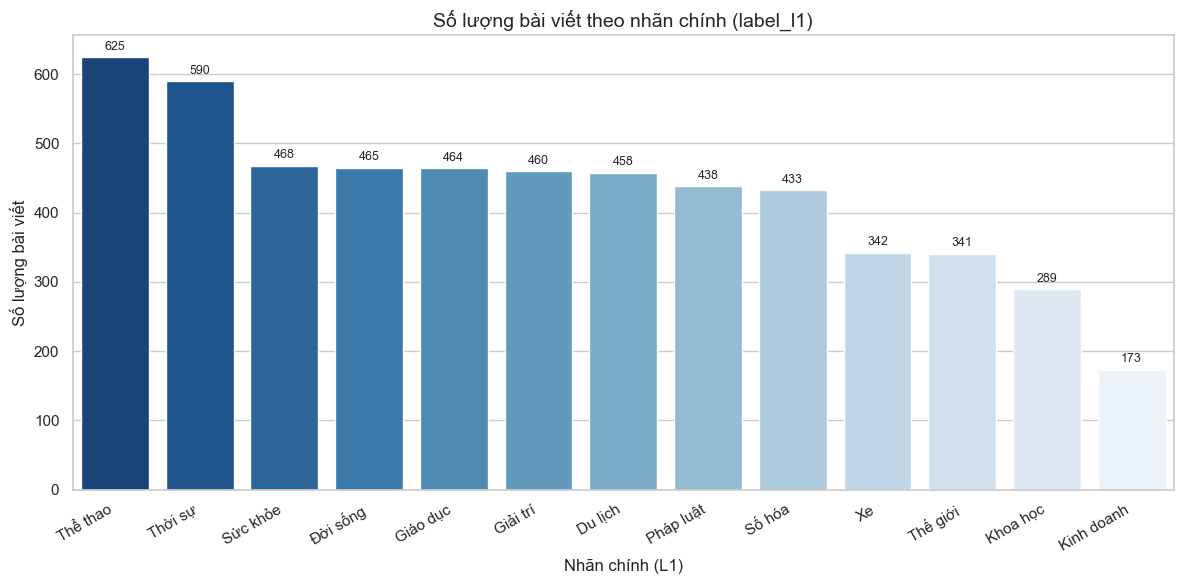

In [4]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='label_l1', y='count', palette='Blues_r')

for i, v in enumerate(df['count']):
    ax.text(i, v + max(df['count']) * 0.01, str(v), ha='center', va='bottom', fontsize=9)

plt.title('Số lượng bài viết theo nhãn chính (label_l1)', fontsize=14)
plt.xlabel('Nhãn chính (L1)')
plt.ylabel('Số lượng bài viết')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

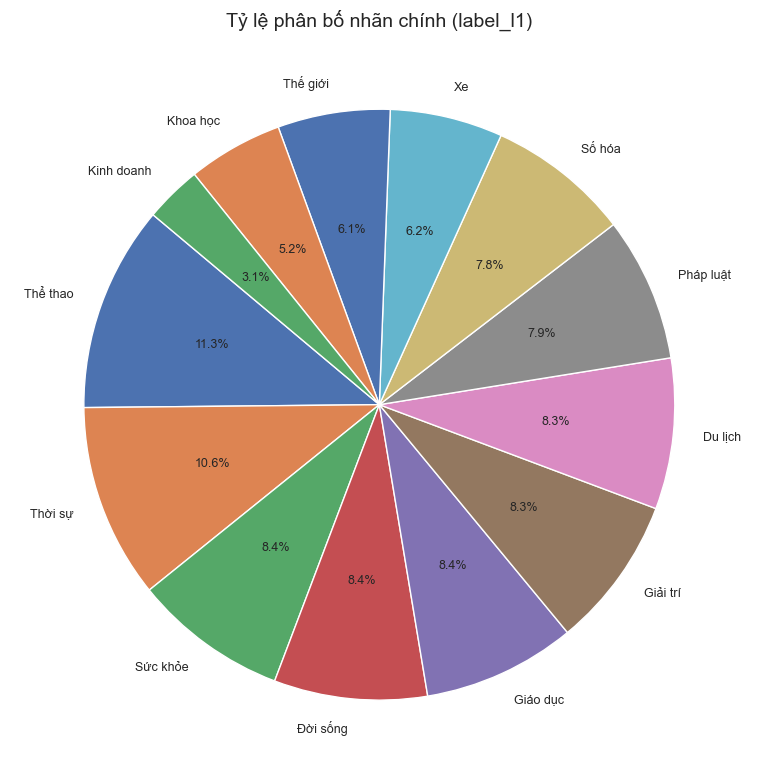

In [5]:
plt.figure(figsize=(8, 8))
plt.pie(
    df['count'],
    labels=df['label_l1'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 9}
)
plt.title('Tỷ lệ phân bố nhãn chính (label_l1)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Nếu cần lưu bảng thống kê ra CSV
# df.to_csv('label_l1_stats.csv', index=False, encoding='utf-8-sig')
df.head(20)

## Thống kê nhãn cấp 2 (L2) và cấp 3 (L3)

Các biểu đồ dưới đây hiển thị **toàn bộ nhãn không rỗng** của `label_l2` và `label_l3`.

In [6]:
def build_label_stats(data, field_name):
    counts = Counter(item.get(field_name, '').strip() for item in data)
    if '' in counts:
        del counts['']

    df_stats = (
        pd.DataFrame(counts.items(), columns=[field_name, 'count'])
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )
    df_stats['percent'] = (df_stats['count'] / df_stats['count'].sum() * 100).round(2)
    return df_stats


def plot_all_labels(df_stats, label_col, title):
    fig_height = max(6, len(df_stats) * 0.35)
    plt.figure(figsize=(14, fig_height))
    ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')

    for i, value in enumerate(df_stats['count']):
        ax.text(value + max(df_stats['count']) * 0.005, i, str(value), va='center', fontsize=9)

    plt.title(title, fontsize=14)
    plt.xlabel('Số lượng bài viết')
    plt.ylabel('Nhãn')
    plt.tight_layout()
    plt.show()

Số nhãn label_l2 (không rỗng): 86


,label_l2,count,percent
0,Tin tức,488,11.02
1,Bóng đá,295,6.66
2,Các bệnh,282,6.37
3,Nhịp sống,200,4.52
4,Giới sao,179,4.04
...,...,...,...
81,Cooking,1,0.02
82,GameVerse 2025,1,0.02
83,esport,1,0.02
84,Bảo hiểm,1,0.02


C:\Users\Admin\AppData\Local\Temp\ipykernel_18780\1556584629.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')


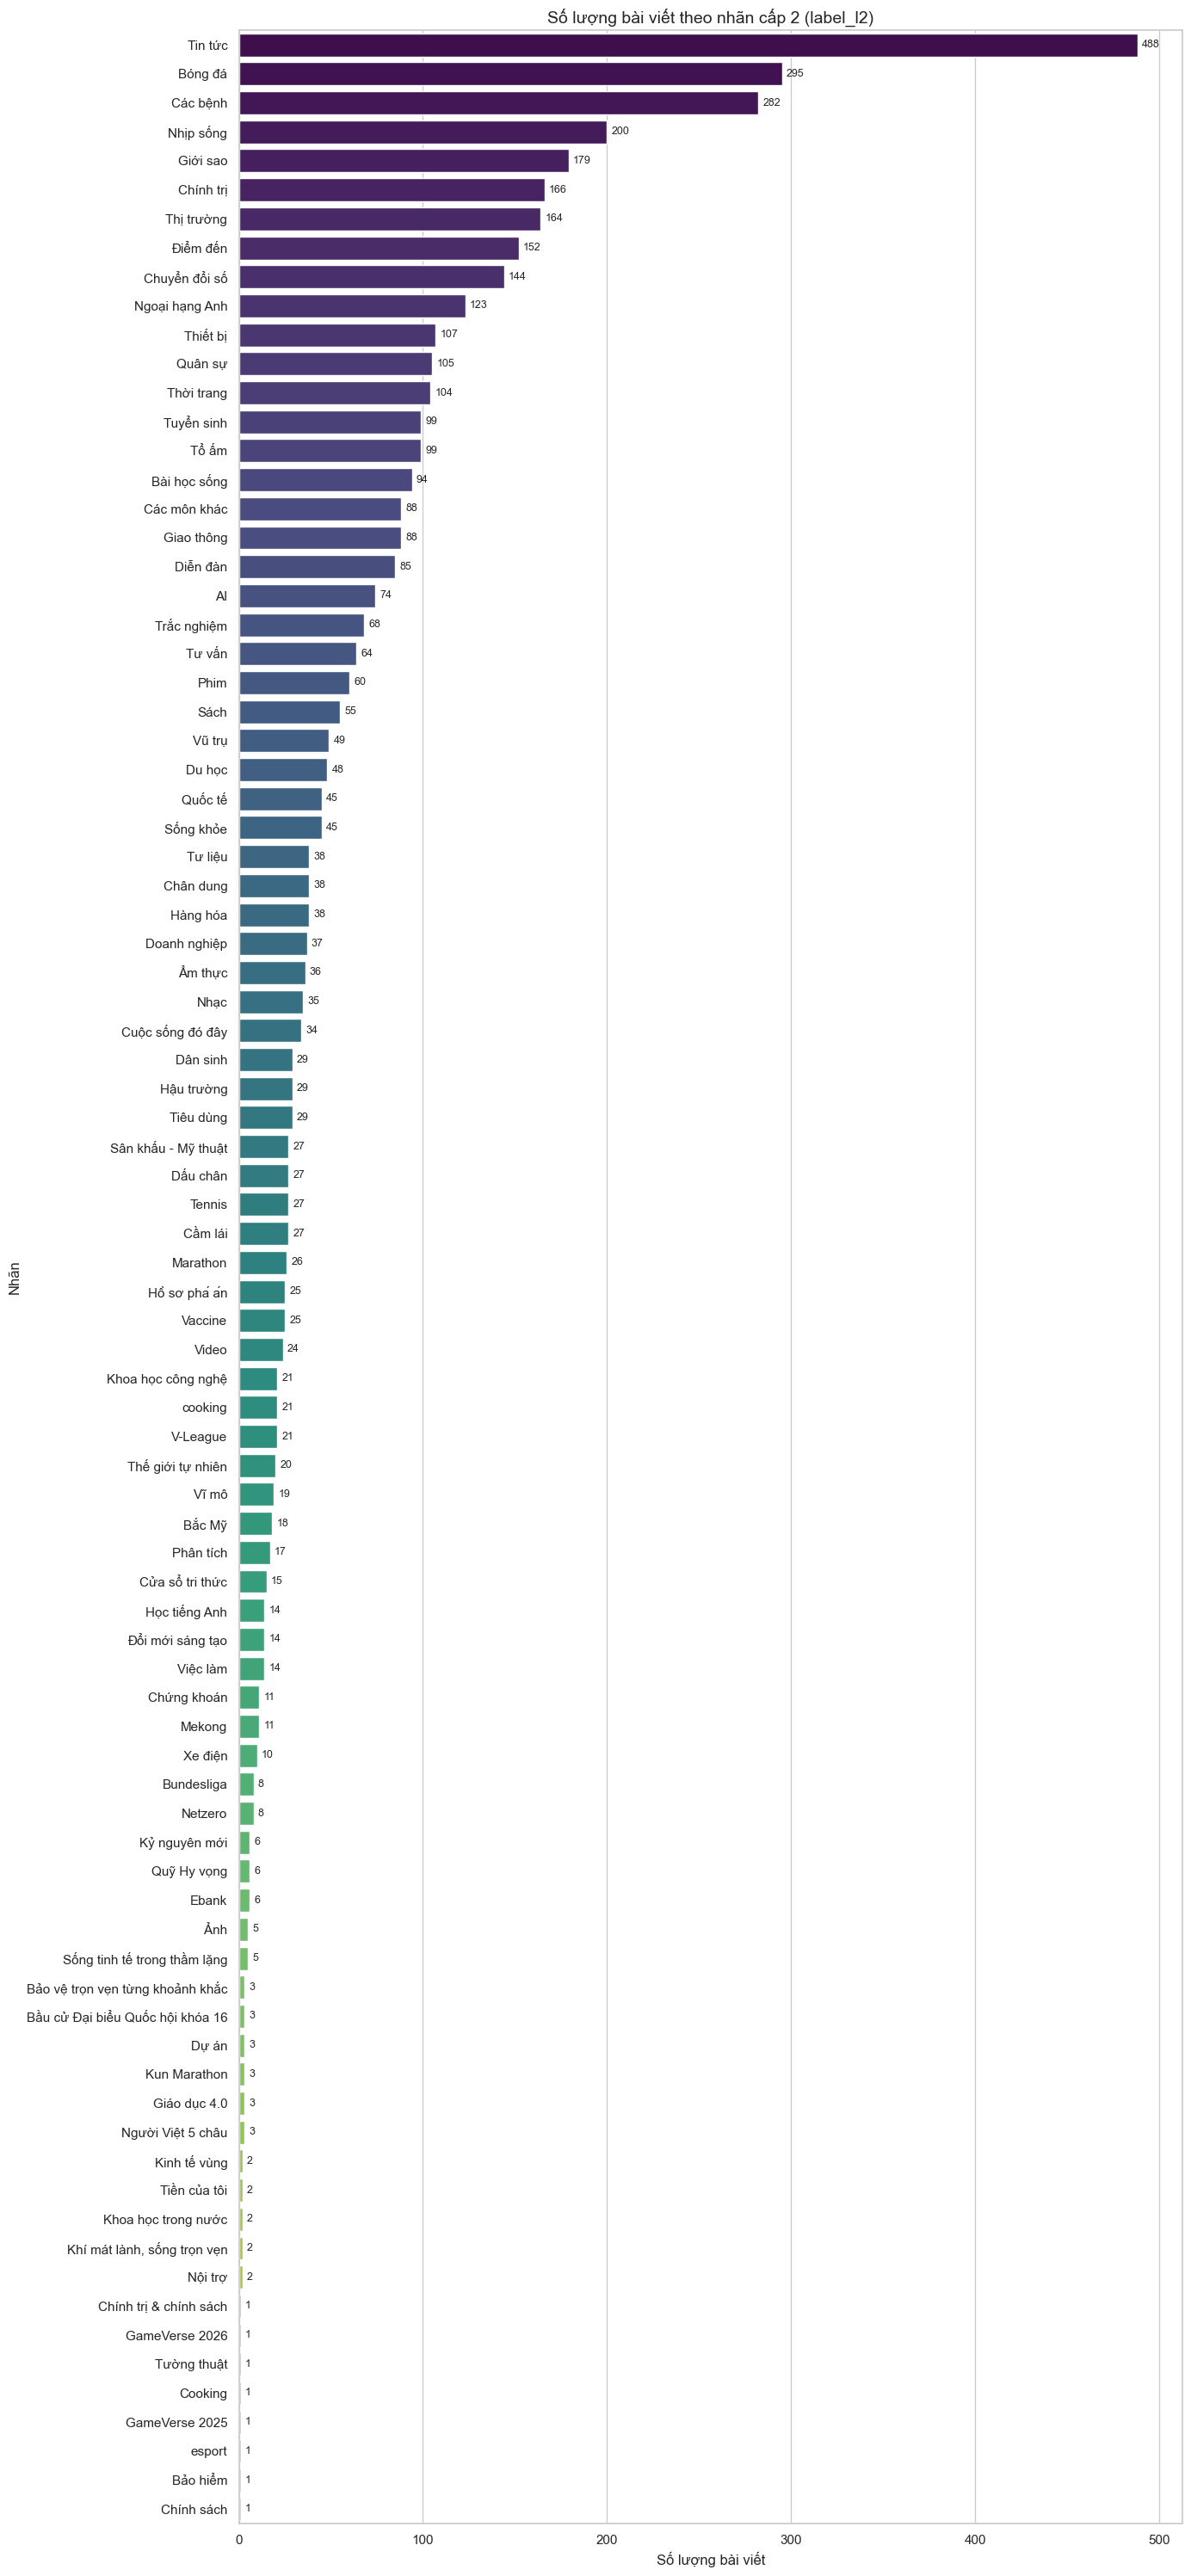

In [7]:
# Thống kê và vẽ biểu đồ cho label_l2

df_l2 = build_label_stats(data, 'label_l2')
print(f"Số nhãn label_l2 (không rỗng): {len(df_l2)}")
display(df_l2)

plot_all_labels(
    df_l2,
    label_col='label_l2',
    title='Số lượng bài viết theo nhãn cấp 2 (label_l2)'
)

Số nhãn label_l3 (không rỗng): 97


,label_l3,count,percent
0,Các giải khác,167,9.02
1,Tin tức,155,8.37
2,Trong nước,152,8.21
3,Nhịp sống số,118,6.37
4,Quốc tế,99,5.35
...,...,...,...
92,VMC,1,0.05
93,Tin dự án,1,0.05
94,Hành tinh kêu cứu,1,0.05
95,Doanh nghiệp xanh,1,0.05


C:\Users\Admin\AppData\Local\Temp\ipykernel_18780\1556584629.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')


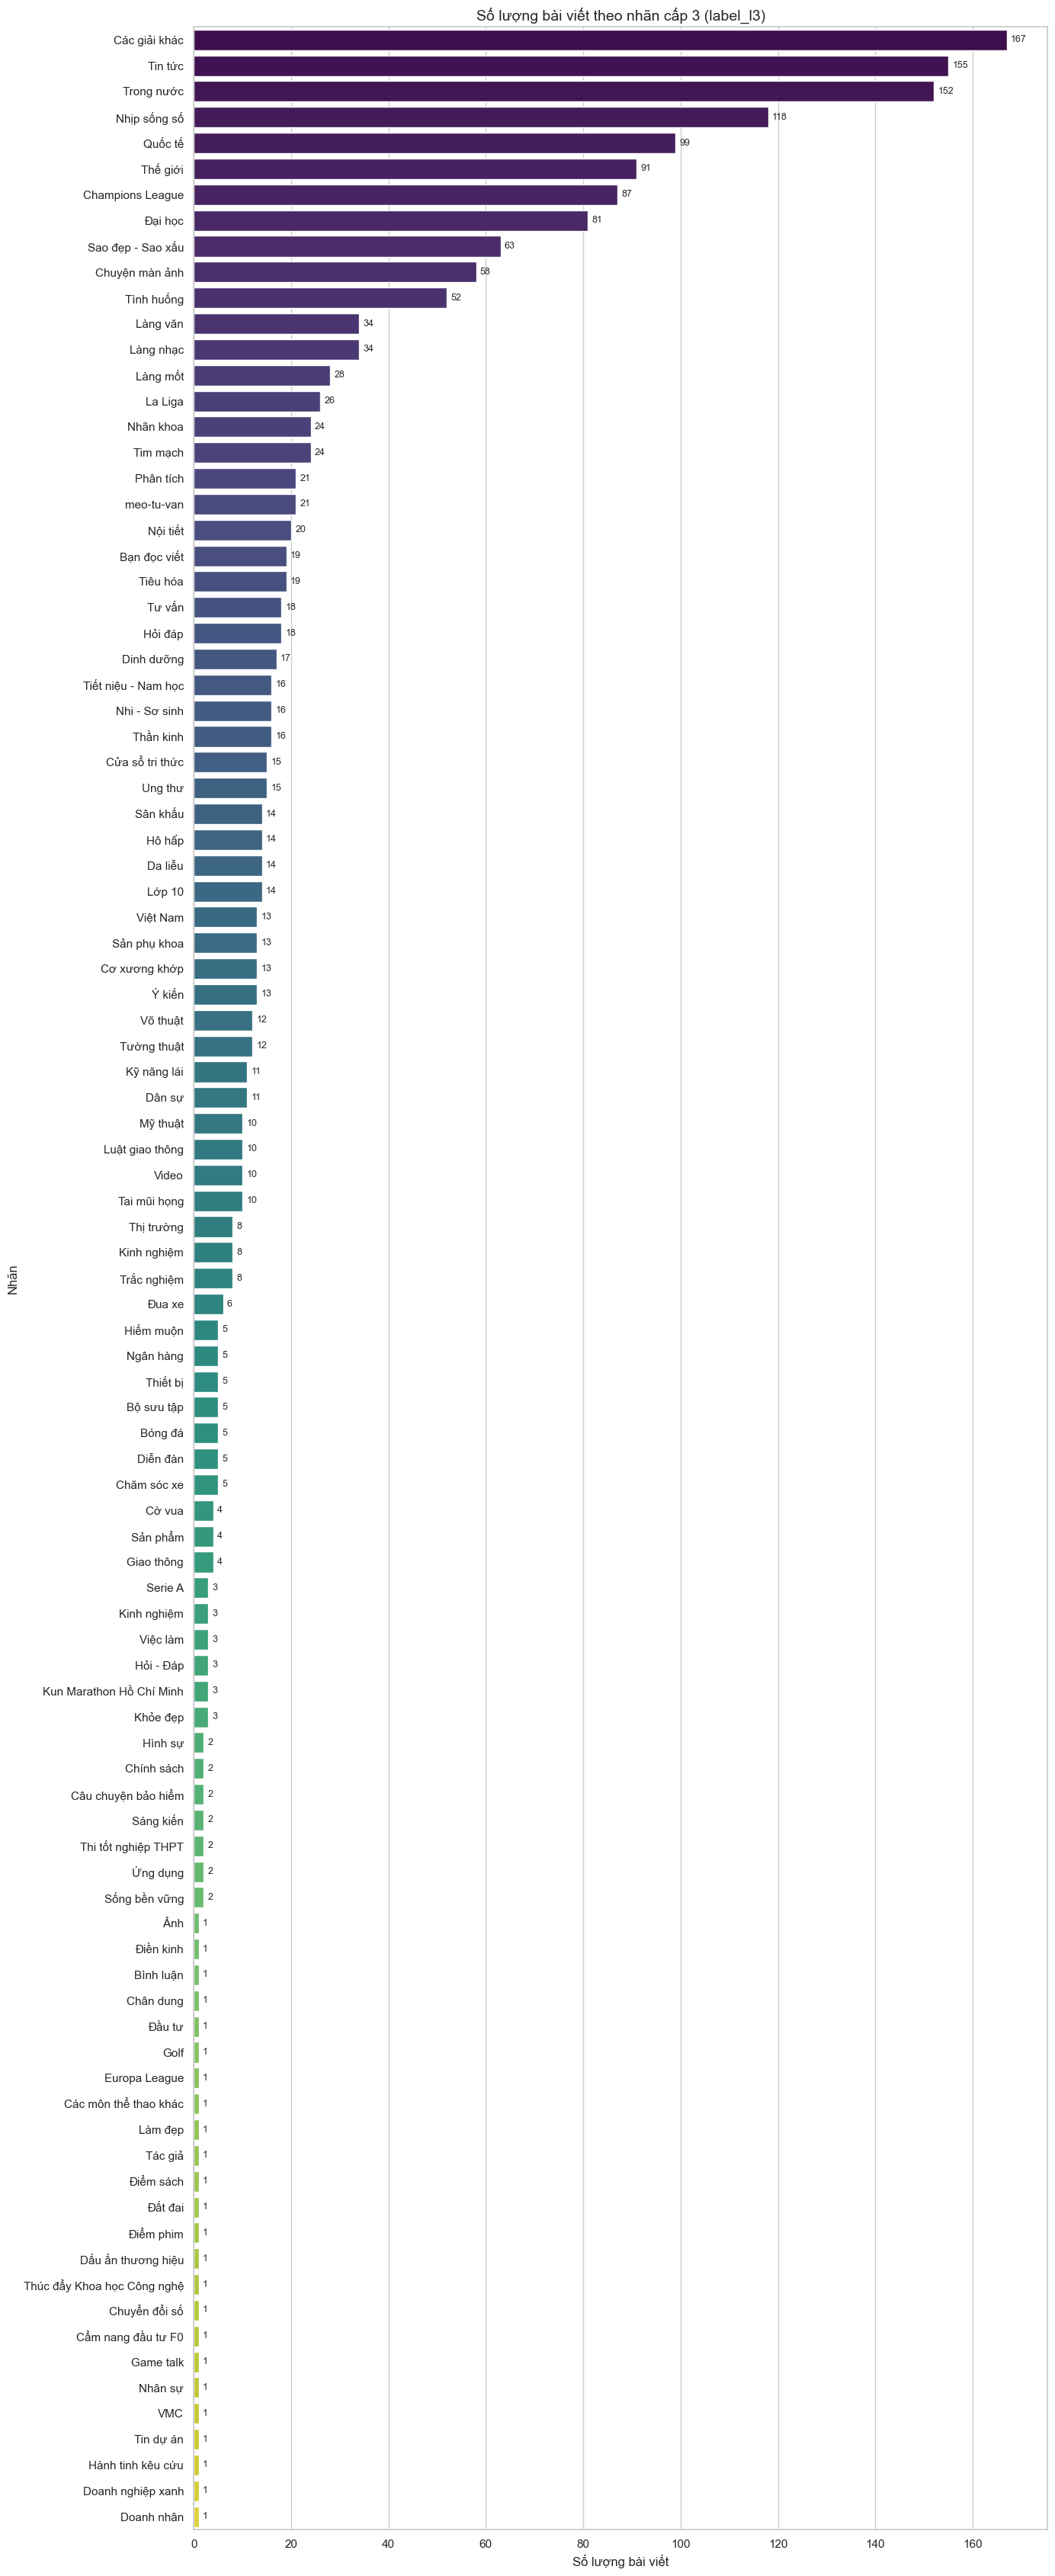

In [8]:
# Thống kê và vẽ biểu đồ cho label_l3

df_l3 = build_label_stats(data, 'label_l3')
print(f"Số nhãn label_l3 (không rỗng): {len(df_l3)}")
display(df_l3)

plot_all_labels(
    df_l3,
    label_col='label_l3',
    title='Số lượng bài viết theo nhãn cấp 3 (label_l3)'
)